<a href="https://colab.research.google.com/github/abhishek-marathe04/makemore/blob/main/building_makemore_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

## We will be following this paper https://jmlr.org/papers/volume3/tmp/bengio03a.pdf

In [77]:
import requests

url = "https://raw.githubusercontent.com/abhishek-marathe04/makemore/refs/heads/main/Indian_names_kaggle.txt"
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    words = response.text.replace(".", "").lower().splitlines()
    print(f"Downloaded {len(words)} names.")
    # print(words[:100])  # Show first 100 characters
else:
    print("Failed to download the file.")

Downloaded 55689 names.


In [78]:
words[:10]

['aaban',
 'aabharan',
 'aabhas',
 'aabhat',
 'aabheer',
 'aabheer',
 'abheer',
 'aabher',
 'aabi',
 'aabilesh']

In [79]:
# Build the vocabulary of characters and mappings to/from integers
# print(sorted(list(set(''.join(words)))))
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [80]:
import torch

block_size = 3
X = []
Y = []
for w in words:

  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)

    # print(''.join(itos[i] for i in context) ,' -->', itos[ix])
    context = context[1:] + [ix]


X = torch.tensor(X)
Y = torch.tensor(Y)

In [81]:
X.shape, Y.shape

(torch.Size([505438, 3]), torch.Size([505438]))

In [82]:
C = torch.randn(27,2)

In [83]:
C[5]

tensor([0.3154, 0.9998])

In [84]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([0.3154, 0.9998])

In [85]:
C[X]

tensor([[[-0.9318, -1.1465],
         [-0.9318, -1.1465],
         [-0.9318, -1.1465]],

        [[-0.9318, -1.1465],
         [-0.9318, -1.1465],
         [ 0.3341,  1.0087]],

        [[-0.9318, -1.1465],
         [ 0.3341,  1.0087],
         [ 0.3341,  1.0087]],

        ...,

        [[ 0.8548, -0.0195],
         [ 0.4539, -0.0724],
         [ 0.3341,  1.0087]],

        [[ 0.4539, -0.0724],
         [ 0.3341,  1.0087],
         [-1.0839,  0.4877]],

        [[ 0.3341,  1.0087],
         [-1.0839,  0.4877],
         [ 0.3341,  1.0087]]])

In [86]:
C[X].shape

torch.Size([505438, 3, 2])

In [87]:
X[13,2]

tensor(1)

In [88]:
C[X[13,2]]

tensor([0.3341, 1.0087])

In [89]:
C[1]

tensor([0.3341, 1.0087])

In [90]:
emb = C[X]
emb.shape

torch.Size([505438, 3, 2])

In [91]:
w1 = torch.randn(6,100)
b1 = torch.randn(100)

In [92]:
# emb @ w1
# RuntimeError: mat1 and mat2 shapes cannot be multiplied (111x2 and 6x100)

In [93]:
(emb.view(-1,6) @ w1) + b1

tensor([[ 1.8191,  0.4580,  1.9799,  ...,  0.2144, -1.8206,  2.7772],
        [-4.2115, -4.1198,  1.0155,  ...,  2.0785, -2.3345, -0.4358],
        [-0.4662,  0.5717,  0.1191,  ...,  0.2507, -5.1949, -1.7644],
        ...,
        [-0.9333, -3.5401,  1.1361,  ..., -1.3279,  0.6384,  0.1213],
        [ 3.3864,  0.7923,  0.3028,  ..., -1.9685,  0.0636,  0.9842],
        [-2.6212, -2.7216,  0.9106,  ..., -0.6426,  1.1726, -1.3582]])

In [94]:
h = torch.tanh((emb.view(X.shape[0],6) @ w1) + b1) # Hidden layer activation

In [95]:
h.shape

torch.Size([505438, 100])

In [96]:
# Lets create final layer
# Input is 100 from hidden layer, and output is 27 possible characters
w2 = torch.randn(100,27)
b2 = torch.randn(27)
logits = h @ w2 + b2

In [97]:
logits.shape

torch.Size([505438, 27])

In [98]:
# We will apply softmax
counts = logits.exp()

In [99]:
prob = counts / counts.sum(1, keepdim=True)

In [100]:
prob.shape

torch.Size([505438, 27])

In [101]:
prob[1].sum()

tensor(1.0000)

In [102]:
torch.arange(32), Y

(tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 tensor([ 1,  1,  2,  ..., 11,  1,  0]))

In [103]:
prob[torch.arange(X.shape[0]), Y]

tensor([8.1992e-05, 9.3047e-06, 4.9656e-12,  ..., 4.4329e-05, 2.2243e-09,
        2.8487e-07])

In [104]:
loss = -prob[torch.arange(X.shape[0]), Y].log().mean()
loss

tensor(15.9303)

In [105]:
F.cross_entropy(logits, Y)

tensor(15.9303)

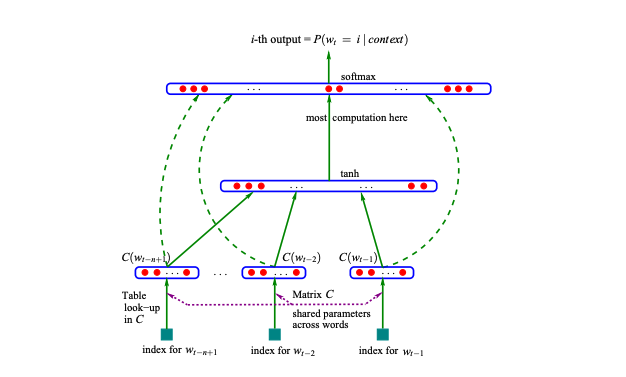

In [106]:
# --------- now made respectable -------

 We will be replicating above neural network where there will be 3 inputs, all will be get indexed to C which is our embedding array. We are storing all characters embedding in 2 dimention format so it will be (27,2) shape.
 Output of this layer would be 6 (2 from each neuron)

 It will then be an input to hidden layer. Our hidden layer will be formed by

> emb * W1 + b1




In [121]:
X.shape, Y.shape

(torch.Size([505438, 3]), torch.Size([505438]))

In [195]:
hidden_layers = 100
g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn(27, 2, generator=g, requires_grad=True)
W1 = torch.randn(6, hidden_layers,generator=g, requires_grad=True)
b1 = torch.randn(hidden_layers, generator=g, requires_grad=True)
W2 = torch.randn(hidden_layers, 27, generator=g, requires_grad=True)
b2 = torch.randn(27, generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]
sum(p.nelement() for p in parameters) # Number of parameters in model

3481

In [196]:
# emb = C[X] # (37,3, 2)
# h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
# logits = h @ W2 + b2 # 37,27
# # counts = logits.exp()
# # prob = counts / counts.sum(1, keepdim=True)
# # loss = -prob[torch.arange(37), Y].log().mean()
# loss = F.cross_entropy(logits, Y)
# loss

We should always use cross entrophy from pytorch instead of our own implemention

Below are few reasons

* Model outputs logits (raw, unnormalized scores), not probabilities.
* Manual softmax can break for large logits, e.g. [100, 0, -100] → exp(100) overflows → inf / nan.

* Computing softmax and log manually can cause numerical instability (overflow → inf / nan).

* F.cross_entropy fuses log_softmax + negative log-likelihood using a numerically stable formulation.

* It is faster, more memory-efficient, and produces cleaner gradients.

* Rule: if your model outputs logits, pass them directly to F.cross_entropy — never apply softmax yourself.

In [197]:
for p in parameters:
  p.requires_grad = True

In [198]:
# torch.randint(0,X.shape[0], (500,)) # We will form minibatch using this

In [199]:
# Lets identify good learning rate
lre = torch.linspace(-3, 0, 1000)

lrs = 10**lre
# for i in range(10):
#     print(lrs[i].item())
# lrs

In [200]:
lri = []
lossi = []
for i in range(1000):
  # Forward pass

  ix = torch.randint(0,X.shape[0], (50,)) # We will form minibatch using this

  emb = C[X[ix]] # (37,3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
  logits = h @ W2 + b2 # 37,27
  loss = F.cross_entropy(logits, Y[ix])
  # loss
  print(loss.item())
  # Backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  lr = lrs[i]
  # Update parameters
  for p in parameters:
      p.data += -lr * p.grad

  # Track loss and lr
  lossi.append(loss.item())
  lri.append(lre[i])


print(loss)

19.670228958129883
22.542505264282227
16.775829315185547
19.728944778442383
17.613515853881836
21.08722686767578
18.822946548461914
20.689390182495117
18.069725036621094
19.733091354370117
21.753089904785156
19.014551162719727
18.312320709228516
19.217884063720703
20.80307388305664
17.589513778686523
19.249303817749023
15.911312103271484
19.60664176940918
19.08479881286621
18.592260360717773
16.689468383789062
20.730405807495117
21.186508178710938
16.544588088989258
19.406700134277344
18.067909240722656
18.8681697845459
18.371013641357422
20.32315444946289
17.8704891204834
18.035463333129883
18.74419593811035
18.4599552154541
18.881956100463867
17.229307174682617
16.414196014404297
17.27213478088379
18.142627716064453
15.618332862854004
19.478227615356445
16.81085777282715
16.940479278564453
16.42438316345215
17.943349838256836
20.024145126342773
18.007282257080078
17.063434600830078
17.59012222290039
19.51482391357422
18.58368682861328
18.65553855895996
18.88175392150879
19.6412372589

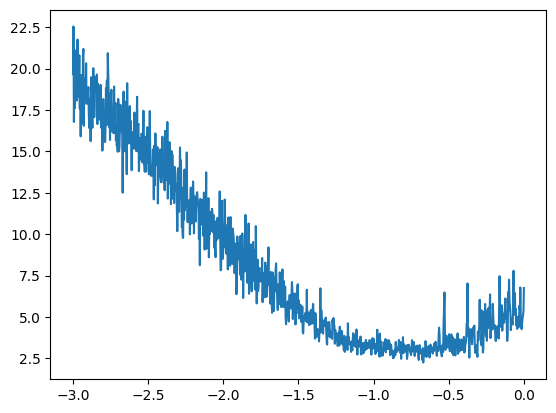

In [201]:
plt.plot(lri, lossi)

From Above Graph, it is clear that good learning exponent is around -1.0 or or 0.1

In [213]:
# Let again initilise everything, Now we know, we will use 0.1 learning rate

hidden_layers = 100
g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn(27, 2, generator=g, requires_grad=True)
W1 = torch.randn(6, hidden_layers,generator=g, requires_grad=True)
b1 = torch.randn(hidden_layers, generator=g, requires_grad=True)
W2 = torch.randn(hidden_layers, 27, generator=g, requires_grad=True)
b2 = torch.randn(27, generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]
sum(p.nelement() for p in parameters) # Number of parameters in model

3481

In [216]:
# Lets run for 30000 iterations
for i in range(30000):
  # Forward pass

  ix = torch.randint(0,X.shape[0], (100,)) # We will form minibatch using this

  emb = C[X[ix]] # (37,3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
  logits = h @ W2 + b2 # 37,27
  # loss
  loss = F.cross_entropy(logits, Y[ix])

  # Backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  lr = 0.1 if i < 20000 else 0.01
  # Update parameters
  for p in parameters:
      p.data += -lr * p.grad


print(loss)

tensor(2.2753, grad_fn=<NllLossBackward0>)


In [217]:
  # Print loss for all of X
emb = C[X] # (37,3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
logits = h @ W2 + b2 # 37,27
loss = F.cross_entropy(logits, Y)
loss

tensor(2.1134, grad_fn=<NllLossBackward0>)

In [218]:
# Lets try to change some hyperparameters now to see if we can improve model. We have used 2 dimention embedding vector, lets try to use 10 dimention now

In [219]:
# Let again initilise everything, Now we know, we will use 10 dimentions in C

hidden_layers = 100
g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn(27, 10, generator=g, requires_grad=True)
W1 = torch.randn(30, hidden_layers,generator=g, requires_grad=True)
b1 = torch.randn(hidden_layers, generator=g, requires_grad=True)
W2 = torch.randn(hidden_layers, 27, generator=g, requires_grad=True)
b2 = torch.randn(27, generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]
sum(p.nelement() for p in parameters) # Number of parameters in model

6097

In [221]:
# Lets run for 30000 iterations
for i in range(30000):
  # Forward pass

  ix = torch.randint(0,X.shape[0], (100,)) # We will form minibatch using this

  emb = C[X[ix]] # (37,3, 2)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (37,100)
  logits = h @ W2 + b2 # 37,27
  # loss
  loss = F.cross_entropy(logits, Y[ix])

  # Backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  lr = 0.1 if i < 20000 else 0.01
  # Update parameters
  for p in parameters:
      p.data += -lr * p.grad


print(loss)

tensor(1.8602, grad_fn=<NllLossBackward0>)


In [222]:
# Loss is good now
# Lets check for whole x
  # Print loss for all of X
emb = C[X] # (37,3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (37,100)
logits = h @ W2 + b2 # 37,27
loss = F.cross_entropy(logits, Y)
loss

tensor(2.0359, grad_fn=<NllLossBackward0>)